In [ ]:
import json
from urllib.request import urlopen

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from nwec.constants import CLEAN_UTILITY_DATA

In [7]:
arrearages = pl.read_ipc(CLEAN_UTILITY_DATA / "arrearage_amounts.arrow")

In [8]:
arrearages

Zip Code,Year,Month,Vintage,Amount,Utility,Customer Class
str,i32,i32,i32,f64,str,str
"""98198""",2024,12,60,2224.2,"""Puget Sound Energy""","""Residential"""
"""99103""",2024,7,30,1267.27,"""Avista Corporation""","""Residential"""
"""98125""",2024,10,60,12203.22,"""Puget Sound Energy""","""Residential"""
"""99403""",2024,3,60,58159.66,"""Avista Corporation""","""Residential"""
"""99013""",2024,7,90,42051.87,"""Avista Corporation""","""Residential"""
…,…,…,…,…,…,…
"""99141""",2024,3,90,23996.27,"""Avista Corporation""","""Residential"""
"""99335""",2024,8,90,0.0,"""Avista Corporation""","""Residential"""
"""98685""",2024,12,90,12856.81,"""Northwest Natural Gas Company""","""Residential"""


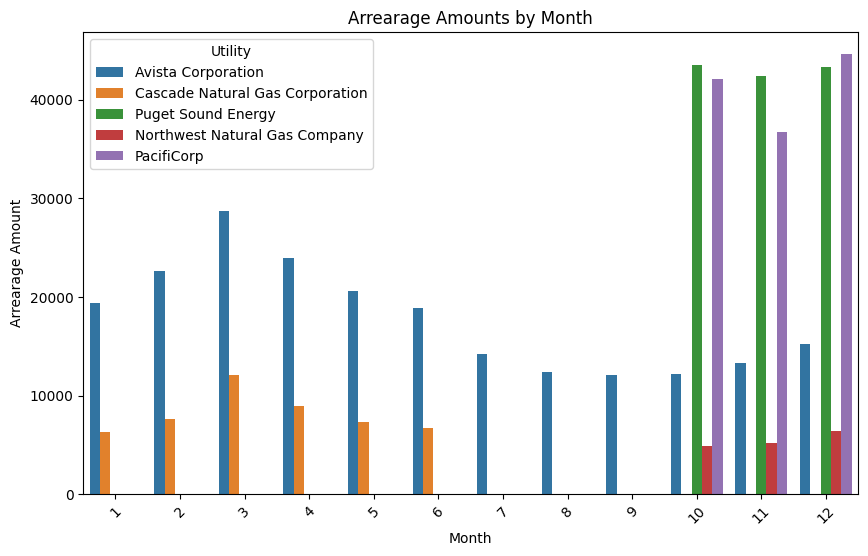

In [9]:
data = arrearages

plt.figure(figsize=(10, 6))
sns.barplot(x="Month", y="Amount", hue="Utility", data=data, errorbar=None)

# Customize the plot
plt.title("Arrearage Amounts by Month")
plt.xlabel("Month")
plt.ylabel("Arrearage Amount")
plt.xticks(rotation=45)  # Rotate month labels

# Show the plot
plt.show()

In [ ]:
# df.group_by("Zip Code", "Vintage", "Month").agg(pl.sum("Amount"))

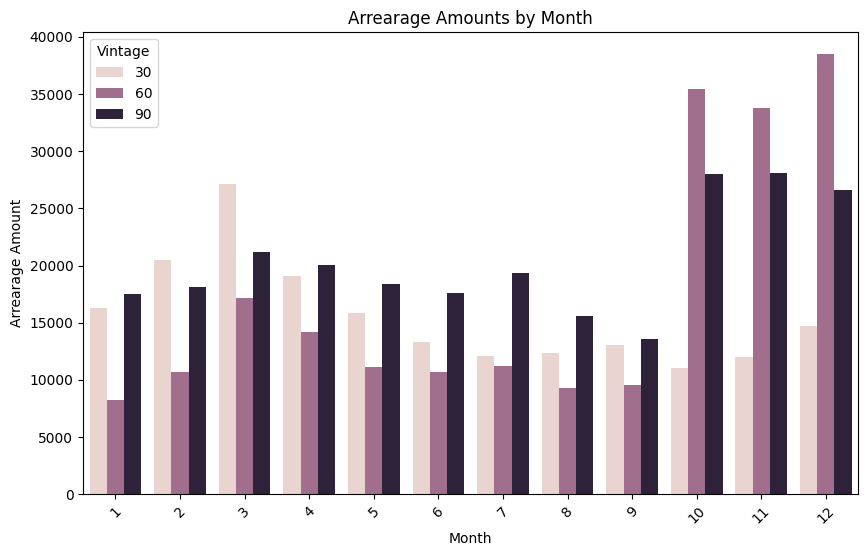

In [ ]:
data = arrearages.group_by("Zip Code", "Vintage", "Month").agg(pl.sum("Amount"))

plt.figure(figsize=(10, 6))
sns.barplot(x="Month", y="Amount", hue="Vintage", data=data, errorbar=None)

# Customize the plot
plt.title("Arrearage Amounts by Month")
plt.xlabel("Month")
plt.ylabel("Arrearage Amount")
plt.xticks(rotation=45)  # Rotate month labels

# Show the plot
plt.show()

In [11]:
with urlopen(
    "https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/refs/heads/master/wa_washington_zip_codes_geo.min.json"
) as response:
    zip_codes = json.load(response)